In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import your custom package
from cooltrack.constants import INDEPENDENT_DIMS
from cooltrack.data_loader import load_and_clean_grid_pandas
from cooltrack.models import ThermalEvolutionModels
from cooltrack.integrator import CoolingIntegrator
from cooltrack.initial_conditions import InitialConditions
from cooltrack.smoothing import TrackSmoother

sns.set_theme(style="whitegrid", context="talk")

# Paths
GRID_FILE_PATH = "../data/HADES_grid/hades_processed_grid.parquet" 
AGE_DATA_PATH = "../data/age_data/"

In [2]:
print("Using cooltrack.data_loader to fetch data...")
df_raw = load_and_clean_grid_pandas(GRID_FILE_PATH)

# Let's use a smaller slice of the data so training is instant for our plot test
df_test_raw = df_raw[df_raw['mass_Mj'] <= 10].copy()
print(f"Loaded {len(df_test_raw):,} rows.")

2026-02-23 03:00:58,855 - INFO - Loading filtered parquet file: ../data/HADES_grid/hades_processed_grid.parquet...


Using cooltrack.data_loader to fetch data...


2026-02-23 03:00:59,110 - INFO - Grid loaded successfully. Final shape: (91613, 13)


Loaded 89,518 rows.


In [3]:
print("Training models and removing numerical noise...")
ml_engine = ThermalEvolutionModels()

# Catch the cleaned dataframe!
df_clean = ml_engine.train_models(df_test_raw, tune_hyperparameters=False, clean_outliers=True)

print(f"Models trained! Retained {len(df_clean):,} clean physics points.")

2026-02-23 03:00:59,128 - INFO - Performing first-pass training to identify grid outliers...


Training models and removing numerical noise...


2026-02-23 03:00:59,655 - INFO - Dropping 1822 corrupted grid points (> 1.0 dex error).
2026-02-23 03:00:59,681 - INFO - Training final T_int state model...
2026-02-23 03:01:01,442 - INFO - Final T_int R^2: 0.9665
2026-02-23 03:01:01,444 - INFO - Training final Radius state model...
2026-02-23 03:01:03,108 - INFO - Final Radius R^2: 0.9986
2026-02-23 03:01:03,121 - INFO - Training final baseline dS/dt model...
2026-02-23 03:01:05,314 - INFO - Final dS/dt test R^2: 0.9957


Models trained! Retained 87,696 clean physics points.


2026-02-23 03:04:50,610 - INFO - Loaded initial condition interpolators from 4 files.


Integrating a track for a 1.0 M_J, 3x Solar Met, 10 M_E Core Jupiter at 150 K...
Simulating Exact Planet:
 - Mass: 1.00 M_J
 - T_irr: 150 K
 - Metallicity: 0.0x Solar
 - Core Mass: 10.0 (Assuming Earth Masses)


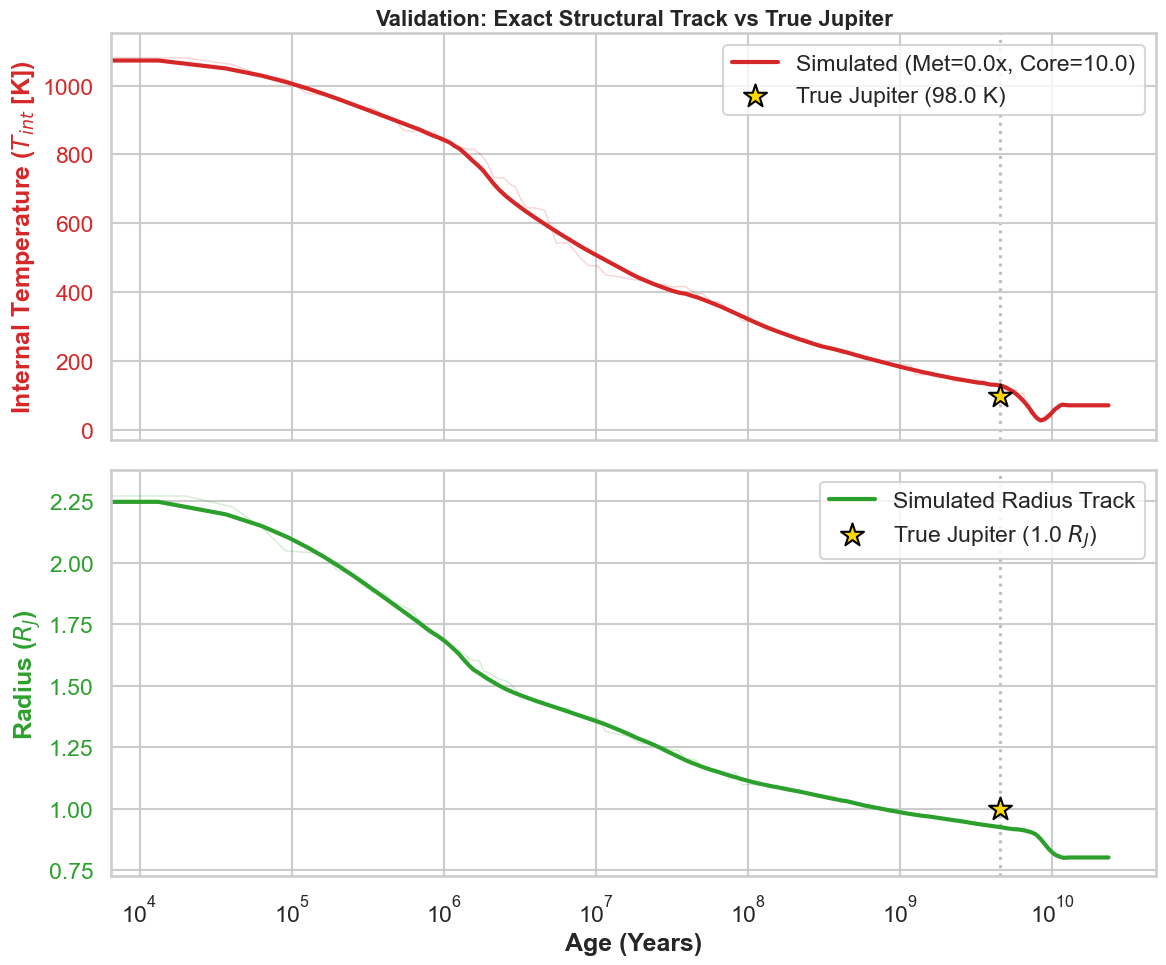

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from cooltrack.smoothing import TrackSmoother
from cooltrack.initial_conditions import InitialConditions
from cooltrack.constants import INDEPENDENT_DIMS

print("Integrating a track for a 1.0 M_J, 3x Solar Met, 10 M_E Core Jupiter at 150 K...")

init_cond = InitialConditions(AGE_DATA_PATH)
integrator = CoolingIntegrator(ml_engine)

# --- True Jupiter Values ---
JUPITER_AGE_YR = 4.56e9   
JUPITER_T_INT_K = 98.0    
JUPITER_RADIUS_RJ = 1.0   
SAFE_T_IRR_K = 150.0      
JUPITER_METALLICITY = 0.0 # 3x Solar
JUPITER_CORE_MASS = 10.0  # 10 Earth masses (adjust if your grid uses fractions!)

# --- Construct the EXACT Planet ---
# Find a baseline planet near our target so the inherited params (like kzz) make sense
baseline_mask = (np.isclose(df_clean['mass_Mj'], 1.0, atol=0.2)) & \
                (df_clean['T_irr'] >= SAFE_T_IRR_K)

baseline_candidates = df_clean[baseline_mask].sort_values('T_irr')

if baseline_candidates.empty:
    print("Could not find a valid baseline planet! Using fallback...")
    planet_row = df_clean.iloc[0].copy() 
else:
    planet_row = baseline_candidates.iloc[0].copy()
    
# OVERRIDE with the EXACT structural parameters we want to simulate!
planet_row['mass_Mj'] = 1.0
planet_row['T_irr'] = SAFE_T_IRR_K
planet_row['Met'] = JUPITER_METALLICITY
planet_row['core'] = JUPITER_CORE_MASS

print(f"Simulating Exact Planet:")
print(f" - Mass: {planet_row['mass_Mj']:.2f} M_J")
print(f" - T_irr: {planet_row['T_irr']:.0f} K")
print(f" - Metallicity: {planet_row['Met']}x Solar")
print(f" - Core Mass: {planet_row['core']} (Assuming Earth Masses)")

# --- Get Initial Conditions ---
s_hot_start = init_cond.get_starting_physical_entropy(planet_row['mass_Mj'], bin_index=19, n_bins=20)
s_cold_end = df_clean['S_physical'].min()

# --- Integrate the Cooling Track ---
ages, entropies = integrator.calculate_track(planet_row, s_hot_start, s_cold_end, num_points=250)

if ages is not None:
    fixed_params = planet_row[INDEPENDENT_DIMS].values.astype(float)
    t_ints_raw = []
    radii_raw = []
    
    for s in entropies:
        inp = np.append(fixed_params, s).reshape(1, -1)
        t_ints_raw.append(ml_engine.tint_model.predict(inp)[0])
        radii_raw.append(ml_engine.radius_model.predict(inp)[0])

    # --- Smooth the Tracks ---
    ages_arr = np.array(ages)
    t_ints_arr = np.array(t_ints_raw)
    radii_arr = np.array(radii_raw)
    
    t_ints_smooth = TrackSmoother.smooth(ages_arr, t_ints_arr, method='savgol', window_length=31, polyorder=3)
    radii_smooth = TrackSmoother.smooth(ages_arr, radii_arr, method='savgol', window_length=31, polyorder=3)
    ages_smooth = TrackSmoother.smooth(ages_arr, ages_arr, method='savgol', window_length=31)

    # --- Plotting (2 Panels) ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Panel 1: Internal Temperature
    color1 = 'tab:red'
    ax1.plot(ages_arr, t_ints_arr, color=color1, lw=1, alpha=0.2)
    ax1.plot(ages_smooth, t_ints_smooth, color=color1, lw=3, label=f"Simulated (Met={JUPITER_METALLICITY}x, Core={JUPITER_CORE_MASS})")
    ax1.scatter([JUPITER_AGE_YR], [JUPITER_T_INT_K], color='gold', edgecolor='black', 
                s=300, marker='*', zorder=5, label=f"True Jupiter ({JUPITER_T_INT_K} K)")
    
    ax1.set_ylabel('Internal Temperature ($T_{int}$ [K])', color=color1, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.axvline(JUPITER_AGE_YR, color='gray', linestyle=':', alpha=0.5, zorder=0)
    ax1.legend(loc="upper right")
    ax1.set_title(f"Validation: Exact Structural Track vs True Jupiter", fontsize=16, fontweight='bold')

    # Panel 2: Radius Evolution
    color2 = 'tab:green'
    ax2.plot(ages_arr, radii_arr, color=color2, lw=1, alpha=0.2)
    ax2.plot(ages_smooth, radii_smooth, color=color2, lw=3, label="Simulated Radius Track")
    ax2.scatter([JUPITER_AGE_YR], [JUPITER_RADIUS_RJ], color='gold', edgecolor='black', 
                s=300, marker='*', zorder=5, label=f"True Jupiter (1.0 $R_J$)")
    
    ax2.set_ylabel('Radius ($R_J$)', color=color2, fontweight='bold')
    ax2.set_xlabel('Age (Years)', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_xscale('log')
    ax2.axvline(JUPITER_AGE_YR, color='gray', linestyle=':', alpha=0.5, zorder=0)
    ax2.legend(loc="upper right")
    
    fig.tight_layout()
    plt.show()
else:
    print("Integration failed.")